# Predictive Maintenance — XGBoost Model

**Goal:** Train a binary classifier to predict machine failure.
<br>
**Input:** Sensor readings + machine type
<br>
**Target:** Machine failure (binary)

## What I expect
- Tool wear and torque will be the most important features
- The temp_diff engineered feature may improve performance
- Raw accuracy will be high but misleading — I'll focus on recall and F1
- SHAP will confirm or contradict my EDA intuitions

## Setup

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                            confusion_matrix,
                            ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder 
import xgboost as xgb
import shap

RANDOM_STATE = 42

## Load and prepare data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

In [3]:
df = df.drop(columns=['UDI', 'Product ID'])

In [4]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
print(le.classes_)

['H' 'L' 'M']


In [5]:
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
print(df['temp_diff'].describe())

count    10000.000000
mean        10.000630
std          1.001094
min          7.600000
25%          9.300000
50%          9.800000
75%         11.000000
max         12.100000
Name: temp_diff, dtype: float64


In [6]:
drop_cols=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = df.drop(columns=drop_cols)
y = df['Machine failure']

print(f"Features: {X.columns.tolist()}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'temp_diff']
Feature matrix shape: (10000, 7)
Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, # 80% train 20% test
    random_state = RANDOM_STATE,
    stratify = y # preserve the 3.4% failure rate in both splits
)

X_train.columns = X_train.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False)
X_test.columns  = X_test.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size: {X_test.shape[0]} rows")
print(f"Failure rate in train: {y_train.mean():.3f}")
print(f"Failure rate in test: {y_test.mean():.3f}")

Train size: 8000 rows
Test size: 2000 rows
Failure rate in train: 0.034
Failure rate in test: 0.034


## Data preparation decisions
- Dropped UDI and Product ID: identifiers, no predictive value
- Label encoded Type: H=0, L=1, M=2 — appropriate for tree-based models
- Engineered temp_diff: explicit encoding of the HDF trigger condition
- Dropped TWF/HDF/PWF/OSF/RNF: would cause data leakage if kept as features
- Used stratified split: preserves 3.4% failure rate in both train and test sets

## Train XGBoost

In [8]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print(f"Negative samples: {neg}")
print(f"Positive samples: {pos}")
print(f"Scale_pos_weight: {scale_pos_weight:.1f}")

Negative samples: 7729
Positive samples: 271
Scale_pos_weight: 28.5


In [9]:
model = xgb.XGBClassifier(
    n_estimators = 200, # number of trees
    max_depth = 4, # max depth of each tree
    learning_rate = 0.1, # how much each tree corrects the previous
    scale_pos_weight = scale_pos_weight, # handle class imbalance
    random_state = RANDOM_STATE,
    eval_metric = 'logloss',
    early_stopping_rounds=20
)

model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")

Best iteration: 199


## Evaluation

In [10]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of failure

In [11]:
print(classification_report(y_test, y_pred, target_names=['No failure', 'Failure']))

              precision    recall  f1-score   support

  No failure       0.99      0.98      0.99      1932
     Failure       0.59      0.84      0.69        68

    accuracy                           0.97      2000
   macro avg       0.79      0.91      0.84      2000
weighted avg       0.98      0.97      0.98      2000



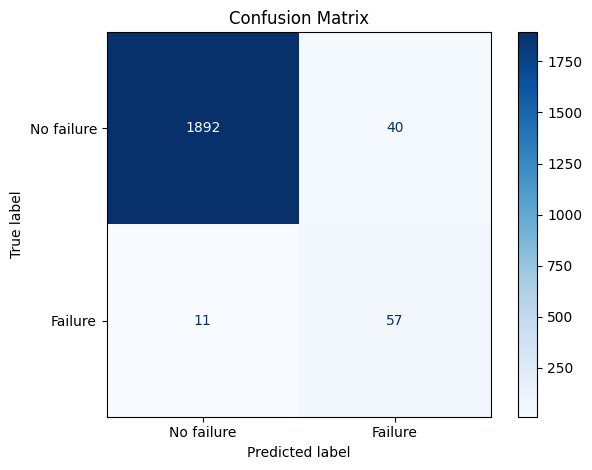

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Evaluation results
- Accuracy is 97% — misleading given the 3.4% failure rate
- Recall for failure class: 84% — 84% of real failures caught
- Precision for failure class: 59% — of predicted failures, only 59% were real
- False negatives (missed failures): 11 — the most costly error in production
- False positives (false alarms): 47 — predicted failure, machine was fine
- Tradeoff chosen: maximize recall, accept lower precision because missing a failure costs more than a false alarm

## SHAP

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

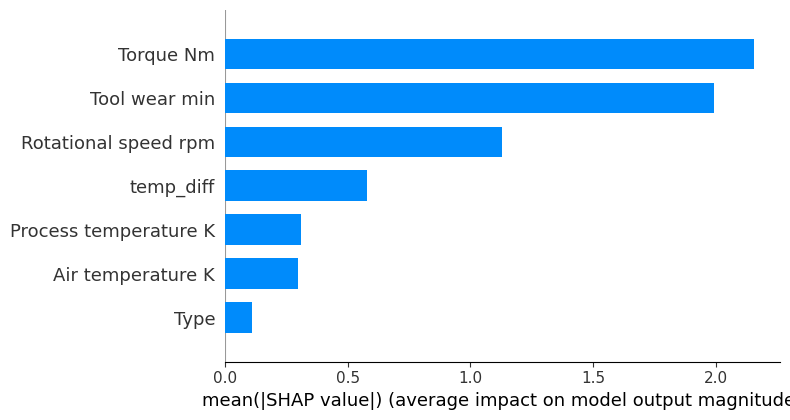

In [14]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

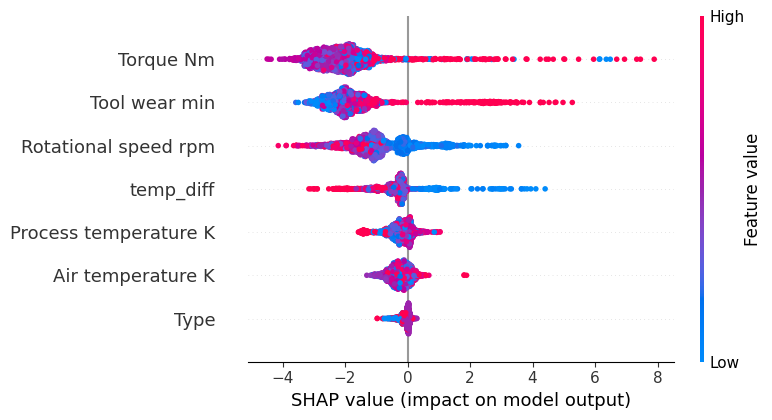

In [15]:
shap.summary_plot(shap_values, X_test)

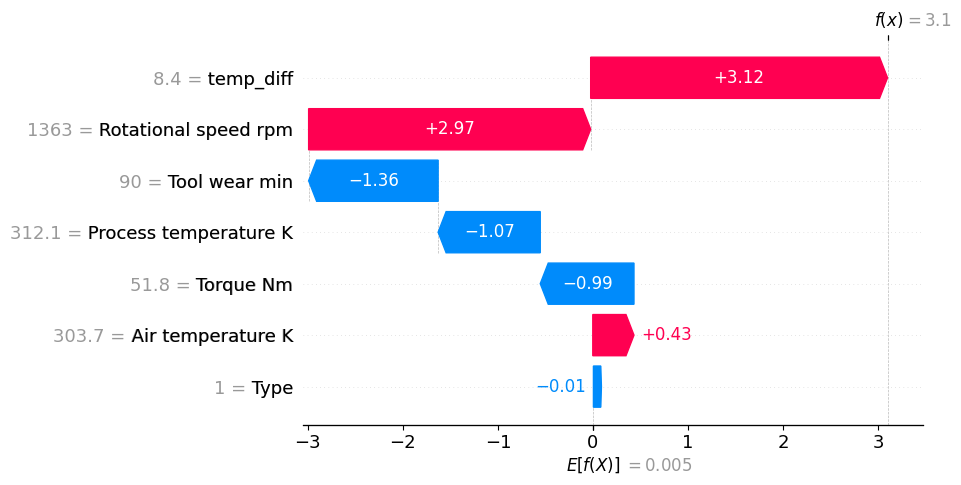

In [16]:
# Pick a failure case — find the index of an actual failure in test set
failure_indices = y_test[y_test == 1].index
sample_idx = failure_indices[0]
sample_position = X_test.index.get_loc(sample_idx)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_position],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_position],
        feature_names=X_test.columns.tolist()
    )
)

## SHAP analysis

**Global feature importance (mean absolute SHAP):**
1. Torque [Nm] — 2.15
2. Tool wear [min] — 1.99
3. Rotational speed [rpm] — 1.13
4. temp_diff — 0.58
5. Process temperature [K] — 0.31
6. Air temperature [K] — 0.30
7. Type — 0.11

- Torque and tool wear dominate globally — consistent with EDA:
  both appear directly in OSF and TWF trigger conditions
- temp_diff ranks 4th globally but becomes the dominant feature
  for individual HDF-type failures — confirms the value of engineering it
- Type ranks last — machine tier has the weakest individual signal

**Single prediction breakdown — sample 4851, predicted at 96% failure:**
- temp_diff = 8.4 K → SHAP +3.12 (strongest push toward failure)
- Rotational speed = 1363 rpm → SHAP +2.97 (second strongest)
- Tool wear = 90 min → SHAP -1.36 (pushing away — tool is not worn)
- Torque = 51.8 Nm → SHAP -0.99 (pushing away — force is moderate)

This is a Heat Dissipation Failure (HDF) pattern: low temp difference
combined with low rotational speed causes overheating regardless of
tool wear or torque. The global importance of torque and tool wear does
not apply to this specific failure mode — SHAP reveals this distinction
at the prediction level, which a global metric would hide entirely.

**Why SHAP over built-in importance:**
Built-in importance counts split frequency — a feature used many times
on small subsets looks more important than one used fewer times on the
full dataset. SHAP measures actual contribution per prediction, accounts
for feature interactions, and is mathematically guaranteed to be the
only fair attribution satisfying consistency and efficiency simultaneously.

## Threshold tuning
**Goal:** find the threshold that maximizes recall while keeping false alarms at an acceptable level for a maintenance context.

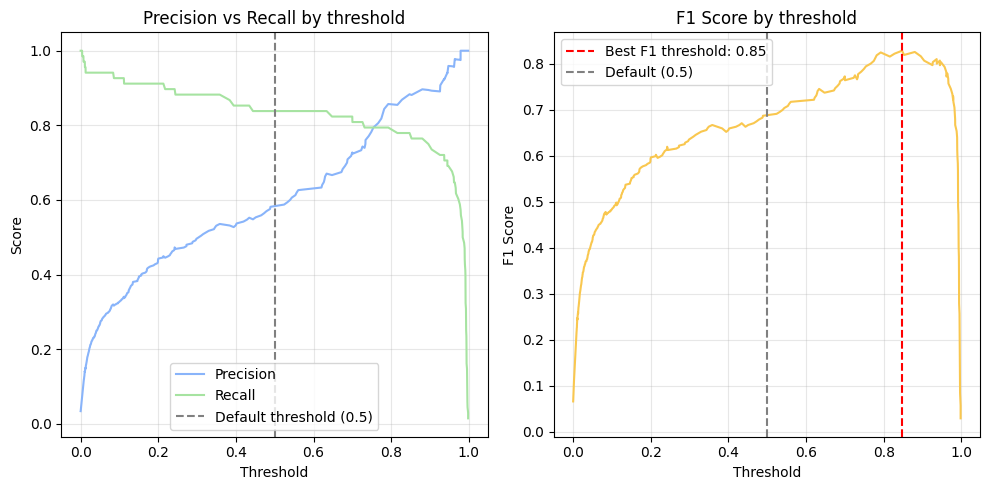

Best F1 threshold: 0.847
Best F1 score: 0.828


In [17]:
from sklearn.metrics import precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 5))

# Left plot — tradeoff curve
plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='#89b4fa')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#a6e3a1')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall by threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Right plot — F1 by threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_threshold_idx = f1_scores.argmax()
best_threshold = thresholds[best_threshold_idx]

plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores, color='#f9c74f')
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best F1 threshold: {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score by threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_threshold:.3f}")
print(f"Best F1 score: {f1_scores[best_threshold_idx]:.3f}")

In [18]:
# Compare default vs optimized threshold
y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)

print("=== DEFAULT THRESHOLD (0.5) ===")
print(classification_report(y_test, y_pred, target_names=['No failure', 'Failure']))

print(f"=== OPTIMIZED THRESHOLD ({best_threshold:.2f}) ===")
print(classification_report(y_test, y_pred_optimized, target_names=['No failure', 'Failure']))

=== DEFAULT THRESHOLD (0.5) ===
              precision    recall  f1-score   support

  No failure       0.99      0.98      0.99      1932
     Failure       0.59      0.84      0.69        68

    accuracy                           0.97      2000
   macro avg       0.79      0.91      0.84      2000
weighted avg       0.98      0.97      0.98      2000

=== OPTIMIZED THRESHOLD (0.85) ===
              precision    recall  f1-score   support

  No failure       0.99      1.00      0.99      1932
     Failure       0.88      0.78      0.83        68

    accuracy                           0.99      2000
   macro avg       0.94      0.89      0.91      2000
weighted avg       0.99      0.99      0.99      2000



## Threshold tuning results
- Default threshold: 0.5
- Optimal threshold for F1: 0.847
- At optimal threshold:
  - Recall: 78% (was 84% at default)
  - Precision: 88% (was 59% at default)
  - F1: 0.83 (was 0.69 at default)
- In production the threshold would be chosen based on the cost ratio between missed failures and false alarms, discussed with the maintenance team — not derived from the data alone